Plots all the SI figures reporting global & local reconstruction error vs some factor

For simulated data, also plot the average values of the null models (no lifting, random lifting)

***no lifting:***

Global reconstruction error mean: 0.4187

Local reconstruction error mean: 0.2543

***Random lifting:***

Global reconstruction error mean: 0.3939

Local reconstruction error mean: 0.2050

In [1]:
import os, sys
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from turtle import title

In [14]:
save_dir = "figures"

In [31]:
def plot_global_error(
    csv_path,
    title,
    fig_path,
    x_col="t_length",
    score_col="mismatch_score",
    repeat_col="repeat",
    min_x=None,
    max_x=None,
    timebin_seconds=None,
    xlabel: str = "Time (s)",
    ylabel: str = "Global reconstruction error (%)",
    show: bool = False,
    xticks=None,
    xtick_labels=None,
    plot_null_errors: bool | str = False,
):
    """
    Plot global error from a CSV file.
    Args:
        csv_path: Path to the CSV file.
        title: Plot title.
        fig_path: Path to save the figure.
        x_col: Name of the time/x column (default 't_length').
        score_col: Name of the score column (default 'mismatch_score').
        repeat_col: Name of the repeat column (default 'repeat').
        min_x: Optional, min value for x_col to include.
        max_x: Optional, max value for x_col to include.
        timebin_seconds: Optional, multiply x_col by this for x-axis.
        xlabel, ylabel: Axis labels.
        show: Whether to show the plot.
        xticks, xtick_labels: Custom x-ticks and labels.
        plot_null_errors: If True/"yes", overlay null-model horizontal lines for no lifting and random lifting.
    """
    def _label_with_percent(label: str) -> str:
        return label.replace("%", r"\%") if plt.rcParams.get("text.usetex", False) else label

    is_plotting_null = str(plot_null_errors).lower() in {"1", "true", "yes", "y"}

    df = pd.read_csv(csv_path)
    if min_x is not None:
        df = df[df[x_col] >= min_x]
    if max_x is not None:
        df = df[df[x_col] <= max_x]

    x_values = sorted(df[x_col].unique())
    
    # Build matrix (repeat x t_values)
    if repeat_col in df.columns:
        repeats = sorted(df[repeat_col].unique())
        mat = np.full((len(x_values), len(repeats)), np.nan)
        for i, x in enumerate(x_values):
            for j, r in enumerate(repeats):
                mask = (df[x_col] == x) & (df[repeat_col] == r)
                if mask.any():
                    val = df.loc[mask, score_col].values[-1]
                    mat[i, j] = pd.to_numeric(val, errors="coerce")
    else:
        mat = df.pivot_table(index=x_col, values=score_col, aggfunc='mean').values.reshape(-1, 1)

    x_vals = np.array(x_values, dtype=float)
    if timebin_seconds is not None:
        x_vals = x_vals * timebin_seconds

    mat_pct = mat * 100.0
    means = np.nanmean(mat_pct, axis=1)
    stds = np.nanstd(mat_pct, axis=1)
    valid = ~np.isnan(means)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.errorbar(
        x_vals[valid],
        means[valid],
        yerr=stds[valid],
        fmt="o-",
        color="navy",
        ecolor="navy",
        markersize=10,
        capsize=4,
        linewidth=2.5,
        elinewidth=2.5,
        capthick=2.5
    )

    if is_plotting_null:
        ax.axhline(0.4187 * 100.0, color="red", linestyle="--", linewidth=2, label="no lifting")
        ax.axhline(0.3939 * 100.0, color="orange", linestyle="--", linewidth=2, label="random lifting")
        ax.legend(loc="best", fontsize = 18)

    ax.set_xlabel(xlabel, fontsize=20)
    ax.set_ylabel(_label_with_percent(ylabel), fontsize=20)
    ax.tick_params(axis="both", which="major", labelsize=20)
    ax.tick_params(axis="both", which="minor", labelsize=20)
    ax.set_title(title, fontsize=20)

    if xticks is not None:
        ax.set_xticks(xticks)
        if xtick_labels is not None:
            ax.set_xticklabels(xtick_labels)

    fig.tight_layout()

    fig.savefig(fig_path, dpi=200)
    print(f"Figure saved to {fig_path}")
    if show:
        plt.show()

    return fig, ax


In [32]:
def plot_segmental_error_summary(
    csv_path: str,
    save_dir: str | None = None,
    x_col: str = "smooth_sigma",
    mean_col: str = "seg_mean",
    std_col: str = "seg_std",
    xlabel: str = "Smoothing factor sigma",
    ylabel: str = "Segmental reconstruction error (%)",
    title: str = "",
    fig_path: str | None = None,
    max_xvalue: float | None = None,
    xticks=None,
    xtick_labels=None,
    plot_null_errors: bool | str = False,
):
    """Plot a sweep summary CSV with seg_mean and seg_std columns."""
    if save_dir is None:
        save_dir = os.path.dirname(csv_path)
    if fig_path is None:
        fig_path = os.path.join(save_dir, "segmental_error_summary.png")

    def _label_with_percent(label: str) -> str:
        return label.replace("%", r"\%") if plt.rcParams.get("text.usetex", False) else label

    is_plotting_null = str(plot_null_errors).lower() in {"1", "true", "yes", "y"}

    if not os.path.exists(csv_path):
        print(f"CSV not found: {csv_path}")
        return None

    df = pd.read_csv(csv_path)
    if df.empty:
        print(f"CSV is empty: {csv_path}")
        return None

    required_cols = {x_col, mean_col, std_col}
    missing_cols = required_cols.difference(df.columns)
    if missing_cols:
        print(f"Missing columns in {csv_path}: {sorted(missing_cols)}")
        return None

    if max_xvalue is not None:
        df = df[df[x_col] <= max_xvalue]

    df = df.dropna(subset=[x_col, mean_col, std_col])
    if df.empty:
        print(f"No valid rows to plot in {csv_path}.")
        return None

    grouped = df.groupby(x_col)
    x_values = sorted(grouped.groups.keys())
    x_plot = np.array(x_values, dtype=float)
    mean_vals = grouped[mean_col].mean().reindex(x_values).to_numpy(dtype=float) * 100.0
    std_vals = grouped[std_col].mean().reindex(x_values).to_numpy(dtype=float) * 100.0

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.errorbar(
        x_plot,
        mean_vals,
        yerr=std_vals,
        fmt="o-",
        color="navy",
        ecolor="navy",
        markersize=10,
        capsize=4,
        linewidth=2.5,
        elinewidth=2.5,
        capthick=2.5,
    )

    if is_plotting_null:
        ax.axhline(0.2543 * 100.0, color="red", linestyle="--", linewidth=2, label="no lifting")
        ax.axhline(0.2050 * 100.0, color="orange", linestyle="--", linewidth=2, label="random lifting")
        ax.legend(loc="best", fontsize = 18)

    ax.set_xlabel(xlabel, fontsize=20)
    ax.set_ylabel(_label_with_percent(ylabel), fontsize=20)
    ax.tick_params(axis="both", which="major", labelsize=20)
    ax.tick_params(axis="both", which="minor", labelsize=20)
    ax.set_title(title, fontsize=20)

    if xticks is not None:
        ax.set_xticks(xticks)
        if xtick_labels is not None:
            ax.set_xticklabels(xtick_labels)

    fig.tight_layout()
    fig.savefig(fig_path, dpi=200)
    print(f"Figure saved to {fig_path}")
    plt.show()
    return fig, ax


In [39]:
def plot_local_error_distribution(
    segment_csv_path: str,
    save_dir: str | None = None,
    x_col: str = "t_length",
    xlabel: str = "Time (s)",
    ylabel: str = "Local reconstruction error (%)",
    title: str = "Local reconstruction error vs duration (2D experimental)",
    fig_path: str | None = None,
    min_xvalue: float | None = None,
    max_xvalue: float | None = None,
    xticks=None,
    xtick_labels=None,
    plot_null_errors: bool | str = False,
):
    """Plot per-segment mismatch trends with per-point scatter and error bars."""
    if save_dir is None:
        save_dir = os.path.dirname(segment_csv_path)

    def _label_with_percent(label: str) -> str:
        return label.replace("%", r"\%") if plt.rcParams.get("text.usetex", False) else label

    is_plotting_null = str(plot_null_errors).lower() in {"1", "true", "yes", "y"}

    if not os.path.exists(segment_csv_path):
        print(f"Segment CSV not found: {segment_csv_path}")
        return None

    df = pd.read_csv(segment_csv_path)
    if df.empty:
        print(f"Segment CSV is empty: {segment_csv_path}")
        return None

    if "segment_mismatch_score" in df.columns:
        score_col = "segment_mismatch_score"
    elif "segment_score" in df.columns:
        score_col = "segment_score"
    elif "seg_score" in df.columns:
        score_col = "seg_score"
    elif "mismatch_score" in df.columns:
        score_col = "mismatch_score"
    else:
        print(
            f"Expected one of ['segment_mismatch_score', 'segment_score', 'seg_score', 'mismatch_score'] in {segment_csv_path}, "
            f"found: {list(df.columns)}"
        )
        return None

    if min_xvalue is not None:
        df = df[df[x_col] >= min_xvalue]
    if max_xvalue is not None:
        df = df[df[x_col] <= max_xvalue]

    x_values = sorted(df[x_col].unique())
    x_plot = np.array(x_values, dtype=float)

    grouped = (
        df.dropna(subset=[score_col])
        .groupby(x_col)[score_col]
    )

    if grouped.ngroups == 0:
        print("No valid segment mismatch scores to plot.")
        return None

    means = grouped.mean().reindex(x_plot).to_numpy(dtype=float) * 100.0
    stds = grouped.std().fillna(0.0).reindex(x_plot).to_numpy(dtype=float) * 100.0

    if len(x_plot) == 0:
        print("No valid segment mismatch scores to plot within the requested x-range.")
        return None

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.errorbar(
        x_plot,
        means,
        yerr=stds,
        fmt="o-",
        color="navy",
        ecolor="navy",
        markersize=10,
        capsize=4,
        linewidth=2.5,
        elinewidth=2.5,
        capthick=2.5,
    )

    if is_plotting_null:
        ax.axhline(0.2543 * 100.0, color="red", linestyle="--", linewidth=2, label="no lifting")
        ax.axhline(0.2050 * 100.0, color="orange", linestyle="--", linewidth=2, label="random lifting")
        ax.legend(loc="best", fontsize = 18)

    ax.set_xlabel(xlabel, fontsize=20)
    ax.set_ylabel(_label_with_percent(ylabel), fontsize=20)
    ax.tick_params(axis="both", which="major", labelsize=20)
    ax.tick_params(axis="both", which="minor", labelsize=20)
    ax.set_title(title, fontsize=20)

    if xticks is not None:
        ax.set_xticks(xticks)
        if xtick_labels is not None:
            ax.set_xticklabels(xtick_labels)

    fig.tight_layout()
    fig.savefig(fig_path, dpi=200)
    print(f"Figure saved to {fig_path}")
    plt.show()
    return fig, ax


## Sweep duration

In [62]:
path_global_error = "sweep_time/sweep_time_gardner_results/Gardner_sweep_time.csv"
path_local_error = "sweep_time/sweep_time_gardner_results/Gardner_sweep_time_segment_scores.csv"

Figure saved to figures/sweep_duration_2D_global.png


/tmp/ipykernel_955616/1120951558.py:66: RuntimeWarning: Mean of empty slice
  means = np.nanmean(mat_pct, axis=1)
/home/hyoon/anaconda3/envs/GridCellDecoding/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


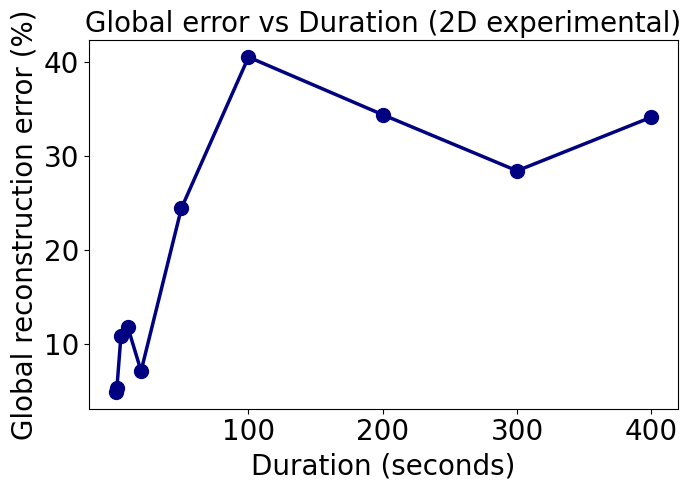

In [63]:
fig, ax= plot_global_error(path_global_error, 
                                      "Global error vs Duration (2D experimental)", 
                                      os.path.join(save_dir, "sweep_duration_2D_global.png"), 
                                      xlabel="Duration (seconds)",
                                      ylabel="Global reconstruction error (%)",
                                      xticks = [10000, 20000, 30000, 40000],
                                    xtick_labels = [100, 200, 300, 400],
                              
                                      show=True)

Figure saved to figures/sweep_duration_2D_local.png


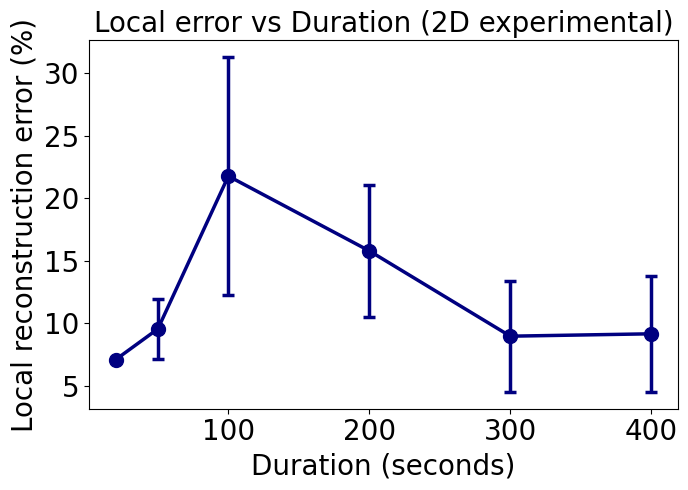

In [64]:

fig, ax = plot_local_error_distribution(path_local_error,
                                         save_dir, 
                                         xlabel = "Duration (seconds)",
                                         ylabel = "Local reconstruction error (%)",
                                         title = "Local error vs Duration (2D experimental)",
                                         fig_path = os.path.join(save_dir, "sweep_duration_2D_local.png"),
                                         xticks = [10000, 20000, 30000, 40000],
                                         xtick_labels = [100, 200, 300, 400] ,
                                         )

In [70]:
path_global_error = "sweep_time/sweep_time_results/sweep_time_simulation_old.csv"
path_local_error = "sweep_time/sweep_time_results/sweep_time_segment_scores_dreimac.csv"

Figure saved to figures/sweep_duration_siimulation_global.png


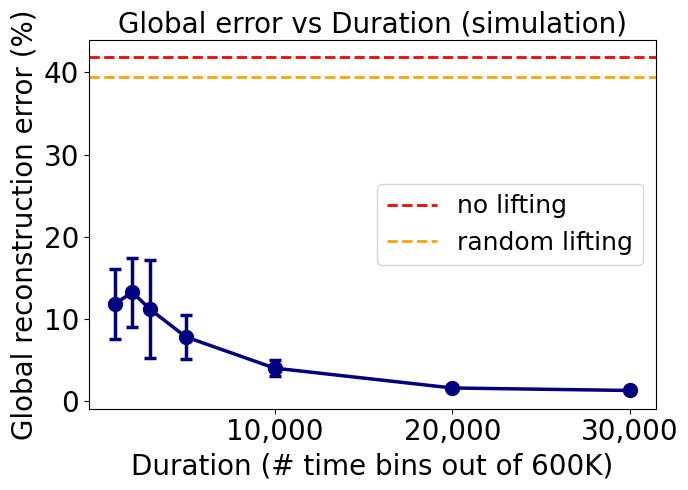

In [68]:
fig, ax= plot_global_error(path_global_error, 
                                      "Global error vs Duration (simulation)", 
                                      os.path.join(save_dir, "sweep_duration_siimulation_global.png"), 
                                      xlabel="Duration (# time bins out of 600K)",
                                      ylabel="Global reconstruction error (%)",
                                      max_x = 30000,
                                      xticks = [10000, 20000, 30000],
                                      xtick_labels = ["10,000", "20,000", "30,000"],
                                      plot_null_errors = True,
                                      show=True)

Figure saved to figures/sweep_duration_simulation_local.png


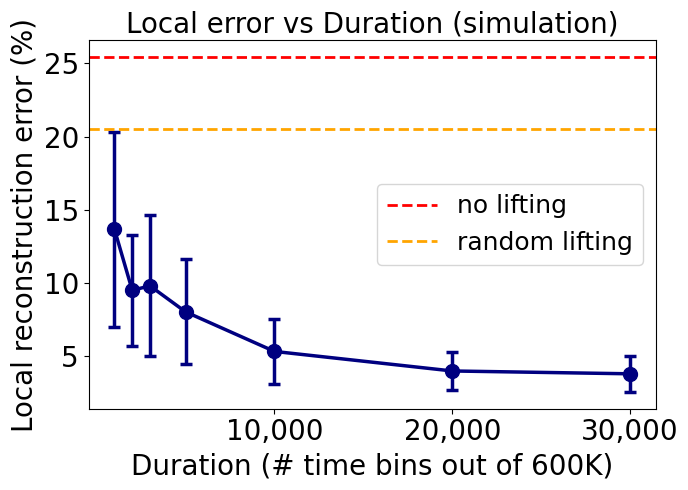

In [73]:
fig, ax = plot_local_error_distribution(path_local_error,
                                         save_dir, 
                                         xlabel = "Duration (# time bins out of 600K)",
                                         ylabel = "Local reconstruction error (%)",
                                         title = "Local error vs Duration (simulation)",
                                         fig_path = os.path.join(save_dir, "sweep_duration_simulation_local.png"),
                                         max_xvalue = 30000,
                                         xticks = [10000, 20000, 30000],
                                         xtick_labels= ["10,000", "20,000", "30,000"],
                                        plot_null_errors = True
                                         )

## neuron count

In [ ]:
path_global_error = "sweep_neuron/sweep_neuron_gardner_results/Gardner_sweep_neuron.csv"
path_local_error = "sweep_neuron/sweep_neuron_gardner_results/Gardner_sweep_neuron_segment_scores.csv"

Figure saved to revision_figures/sweep_neuron_2D_global.png


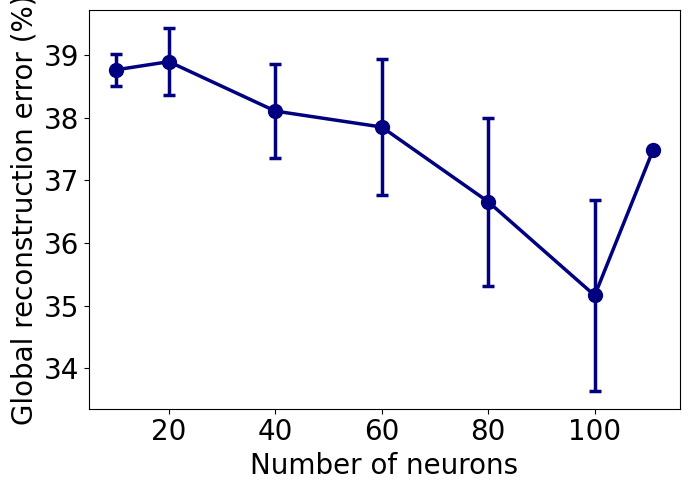

In [47]:
fig, ax= plot_global_error(path_global_error, 
                                      "", 
                                      os.path.join(save_dir, "sweep_neuron_2D_global.png"), 
                                      x_col = "n_neurons",
                                      #max_x = 100,
                                      xlabel="Number of neurons",
                                      ylabel="Global reconstruction error (%)",
                                      show=True)

Figure saved to revision_figures/sweep_neurons_2D_local.png


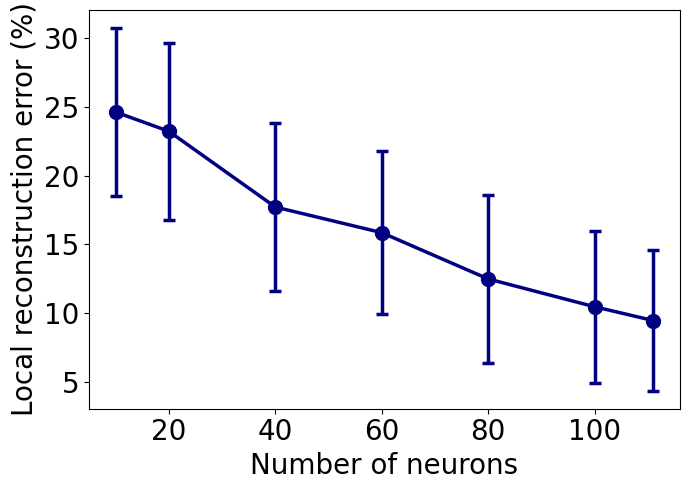

In [48]:

fig, ax = plot_local_error_distribution(path_local_error,
                                         save_dir, 
                                         x_col = "n_neurons",
                                         xlabel = "Number of neurons",
                                         ylabel = "Local reconstruction error (%)",
                                         title = "",
                                         fig_path = os.path.join(save_dir, "sweep_neurons_2D_local.png"),
                                           # max_xvalue = 100,                                           
                                         )

In [74]:
path_global_error = "sweep_neuron/sweep_neuron_results/sweep_neuron.csv"
path_local_error = "sweep_neuron/sweep_neuron_results/sweep_neuron_all_seg_scores.csv"

Figure saved to figures/sweep_neurons_simulation_global.png


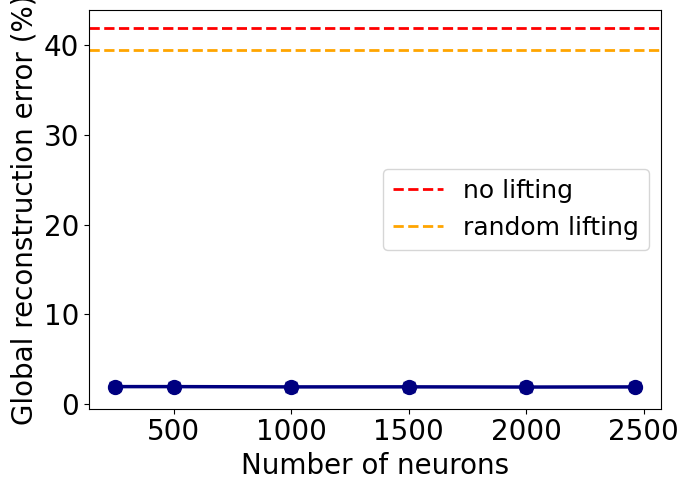

In [76]:
fig, ax= plot_global_error(path_global_error, 
            "", 
            os.path.join(save_dir, "sweep_neurons_simulation_global.png"), 
            x_col = "n_neurons",
            #max_x = 100,
            min_x = 150,
            xlabel="Number of neurons",
            ylabel="Global reconstruction error (%)",
            plot_null_errors = True,
            show=True)


Figure saved to figures/sweep_neurons_simulation_local.png


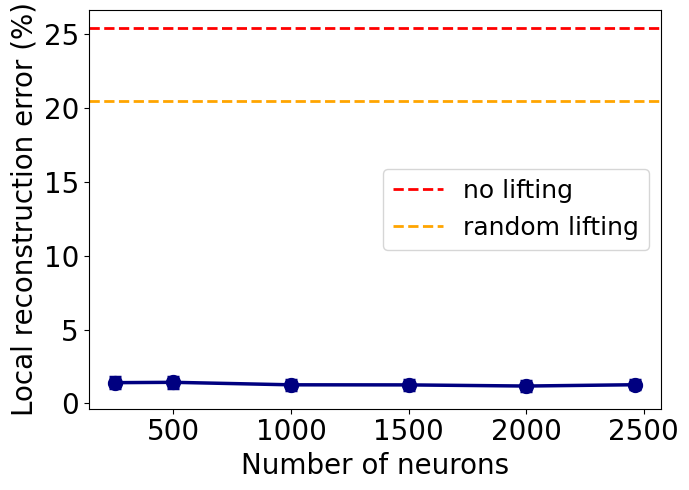

In [77]:
fig, ax = plot_local_error_distribution(path_local_error,
                                         save_dir, 
                                         x_col = "n_neurons",
                                         xlabel = "Number of neurons",
                                         ylabel = "Local reconstruction error (%)",
                                         title = "",
                                         fig_path = os.path.join(save_dir, "sweep_neurons_simulation_local.png"),
                                         min_xvalue = 150,
                                           # max_xvalue = 100, 
                                          plot_null_errors = True                                          
                                         )

## Smoothing the reconstructed path

In [6]:
path_error = "sweep_smooth_sigma/sweep_smooth_sigma_gardner_results/Gardner_sweep_smooth_sigma.csv"

Figure saved to revision_figures/sweep_sigma_2D_global.png


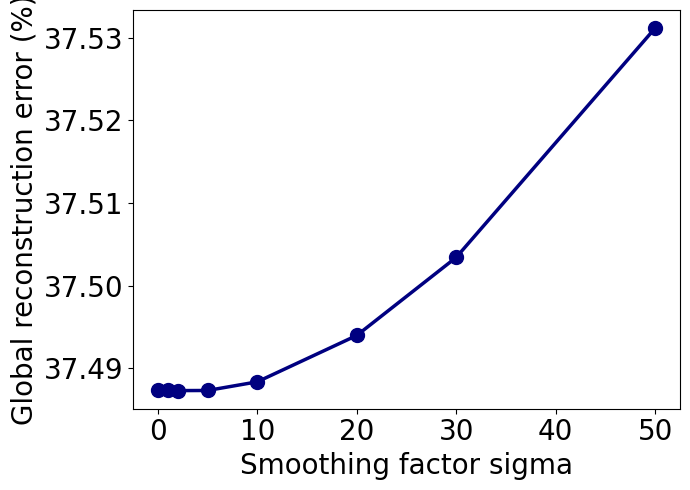

In [7]:
fig, ax= plot_global_error(path_error, 
            "", 
            os.path.join(save_dir, "sweep_sigma_2D_global.png"), 
            x_col = "smooth_sigma",
            #max_x = 100,
            xlabel="Smoothing factor sigma",
            ylabel="Global reconstruction error (%)",
            show=True)


Figure saved to revision_figures/sweep_sigma_2D_local.png


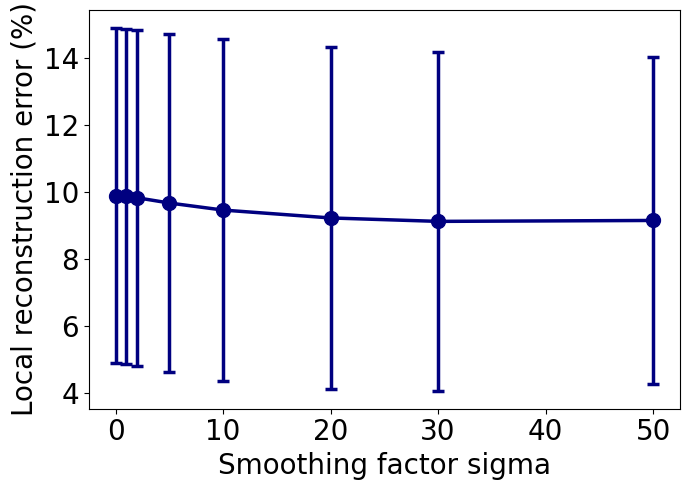

(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='Smoothing factor sigma', ylabel='Local reconstruction error (%)'>)

In [8]:
plot_segmental_error_summary(path_error,
                             save_dir, 
                             x_col="smooth_sigma",
                              xlabel="Smoothing factor sigma", 
                              ylabel="Local reconstruction error (%)", 
                              #title="Local error vs Smoothing (2D experimental)", 
                              fig_path=os.path.join(save_dir, "sweep_sigma_2D_local.png"))




## Smoothing toroidal coordinates

In [15]:
path_global_error = "sweep_noise/gaussian_noise_toroidal_results/gaussian_noise_toroidal_sweep_new.csv"
path_local_error = "sweep_noise/gaussian_noise_toroidal_results/gaussian_noise_toroidal_sweep_segmental_new.csv"


Figure saved to revision_figures/sweep_toroidal_coords_global.png


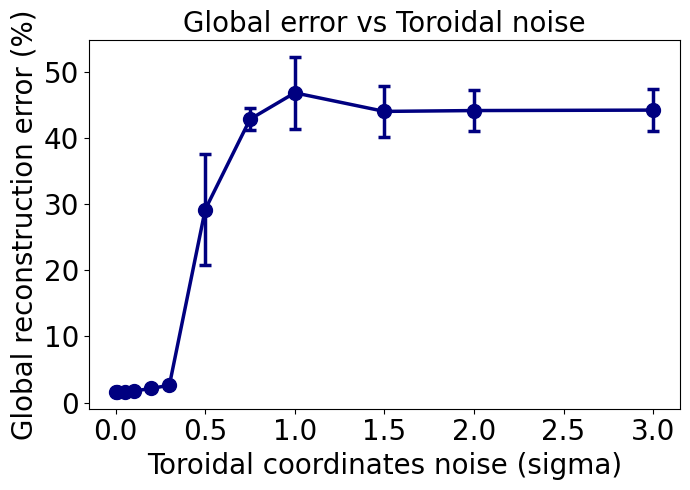

In [26]:
fig, ax= plot_global_error(path_error, 
            "Global error vs Toroidal noise", 
            os.path.join(save_dir, "sweep_toroidal_coords_global.png"), 
            x_col = "sigma",
            #max_x = 100,
            xlabel="Toroidal coordinates noise (sigma)",
            ylabel="Global reconstruction error (%)",
            show=True)


Figure saved to revision_figures/sweep_toroidal_coords_local.png


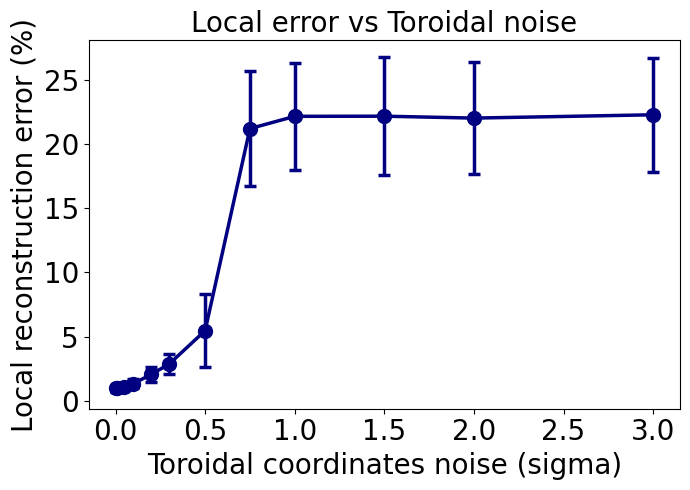

In [27]:
fig, ax = plot_local_error_distribution(path_local_error,
                                         save_dir, 
                                         x_col = "sigma",
                                         xlabel = "Toroidal coordinates noise (sigma)",
                                         ylabel = "Local reconstruction error (%)",
                                         title = "Local error vs Toroidal noise",
                                         fig_path = os.path.join(save_dir, "sweep_toroidal_coords_local.png"),
                                         )

## Sweep Uniform Downsampling - Gardner

In [10]:
path_global_error = "sweep_downsampling/downsample_sweep_gardner_results/Gardner_downsample_sweep.csv"



Figure saved to revision_figures/uniform_downsample_2D.pdf


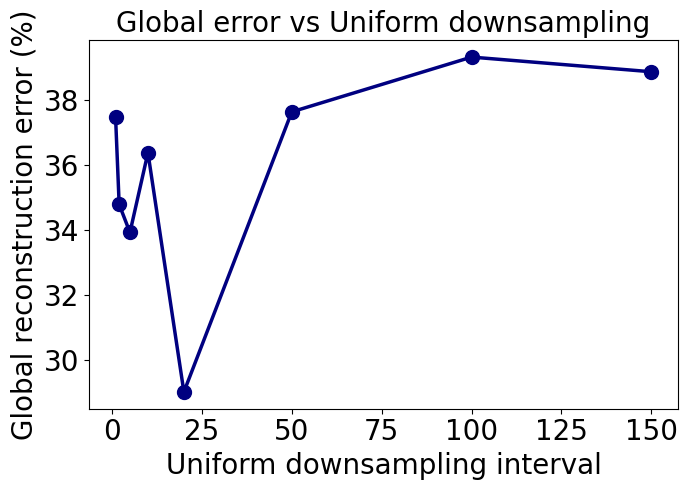

In [11]:
fig, ax= plot_global_error(path_global_error, 
            "Global error vs Uniform downsampling", 
            os.path.join(save_dir, "uniform_downsample_2D.pdf"), 
            x_col = "downsample_interval",
            max_x = 150,
            xlabel="Uniform downsampling interval",
            ylabel="Global reconstruction error (%)",
            show=True)

Figure saved to revision_figures/Uniform_downsampl_local_2D.pdf


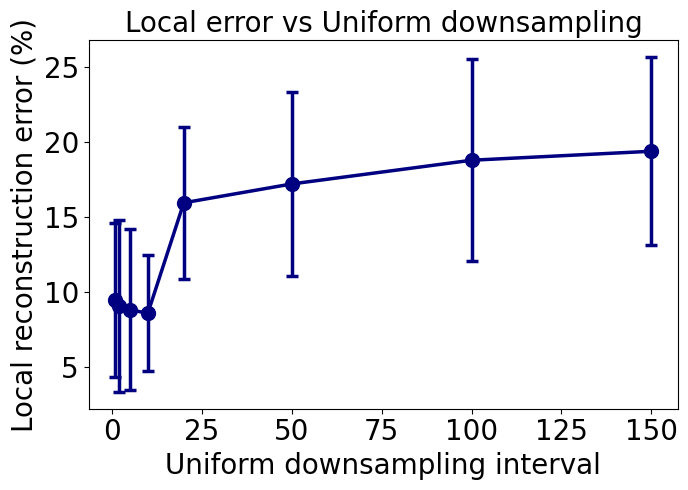

In [12]:
fig, ax = plot_local_error_distribution(path_global_error,
                                         save_dir, 
                                         max_xvalue= 150,
                                         x_col = "downsample_interval",
                                         xlabel = "Uniform downsampling interval",
                                         ylabel = "Local reconstruction error (%)",
                                         title = "Local error vs Uniform downsampling",
                                         fig_path = os.path.join(save_dir, "Uniform_downsampl_local_2D.pdf"),
                                         )

## Sweep nonuniform Downsampling - Gardner

In [13]:
path_global_error = "sweep_downsampling/downsample_poisson_sweep_gardner_results/Gardner_downsample_poisson_sweep.csv"



Figure saved to revision_figures/Poisson_downsample_2D.pdf


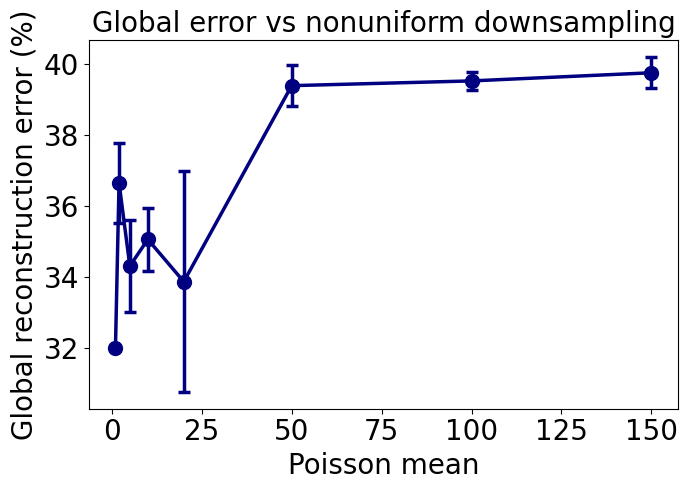

In [14]:
fig, ax= plot_global_error(path_global_error, 
            "Global error vs nonuniform downsampling", 
            os.path.join(save_dir, "Poisson_downsample_2D.pdf"), 
            x_col = "mean_interval",
            max_x = 150,
            xlabel="Poisson mean",
            ylabel="Global reconstruction error (%)",
            show=True)

Figure saved to revision_figures/Poisson_downsample_local_2D.pdf


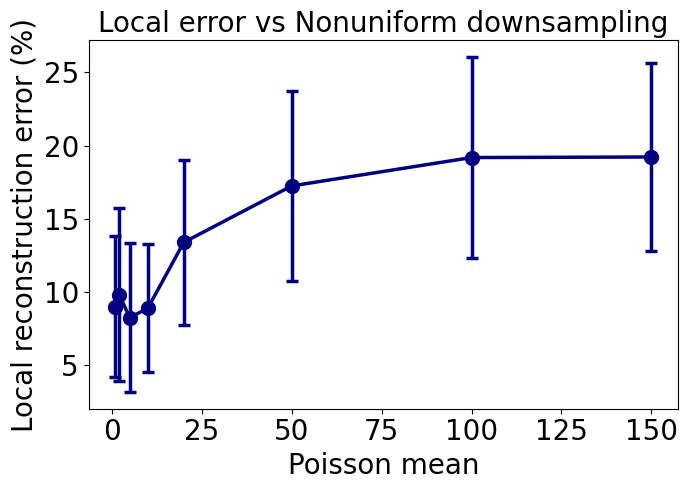

In [15]:
fig, ax = plot_local_error_distribution(path_global_error,
                                         save_dir, 
                                         max_xvalue= 150,
                                         x_col = "mean_interval",
                                         xlabel = "Poisson mean",
                                         ylabel = "Local reconstruction error (%)",
                                         title = "Local error vs Nonuniform downsampling",
                                         fig_path = os.path.join(save_dir, "Poisson_downsample_local_2D.pdf"),
                                         )

## Uniform downsampling, simulation

In [55]:
path_global_error = "sweep_downsampling/downsample_sweep_results/downsample_sweep_1holes.csv"


Figure saved to figures/uniform_downsample_simulation.pdf


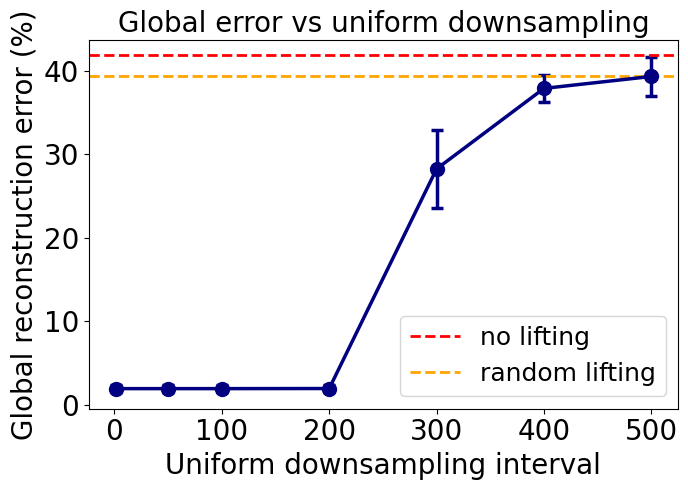

In [57]:
fig, ax= plot_global_error(path_global_error, 
            "Global error vs uniform downsampling", 
            os.path.join(save_dir, "uniform_downsample_simulation.pdf"), 
            x_col = "downsample_interval",
            #max_x = 150,
            xlabel="Uniform downsampling interval",
            ylabel="Global reconstruction error (%)",
            plot_null_errors = True,
            show=True)

Figure saved to figures/uniform_downsample_local_simulation.pdf


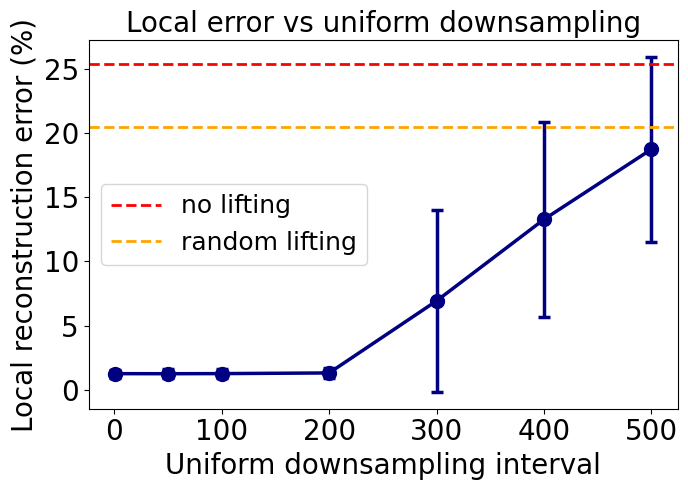

In [58]:
fig, ax = plot_local_error_distribution(path_global_error,
                                         save_dir, 
                                         #max_xvalue= 150,
                                         x_col = "downsample_interval",
                                         xlabel = "Uniform downsampling interval",
                                         ylabel = "Local reconstruction error (%)",
                                         title = "Local error vs uniform downsampling",
                                         fig_path = os.path.join(save_dir, "uniform_downsample_local_simulation.pdf"),
                                         plot_null_errors = True
                                         )

## Nonniform downsampling, simulation

In [59]:
path_global_error = "sweep_downsampling/downsample_poisson_sweep_results/downsample_poisson_sweep_1holes.csv"


Figure saved to figures/nonuniform_downsample_simulation.pdf


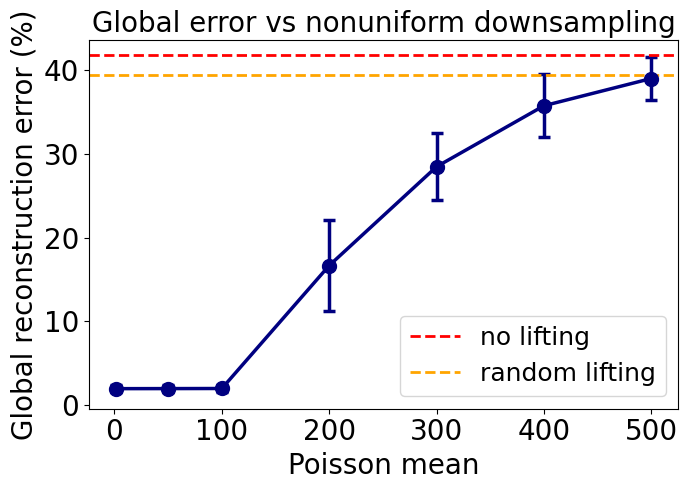

In [60]:
fig, ax= plot_global_error(path_global_error, 
            "Global error vs nonuniform downsampling", 
            os.path.join(save_dir, "nonuniform_downsample_simulation.pdf"), 
            x_col = "mean_interval",
            #max_x = 150,
            xlabel="Poisson mean",
            ylabel="Global reconstruction error (%)",
            plot_null_errors = True,
            show=True)

Figure saved to figures/nonuniform_downsample_local_simulation.pdf


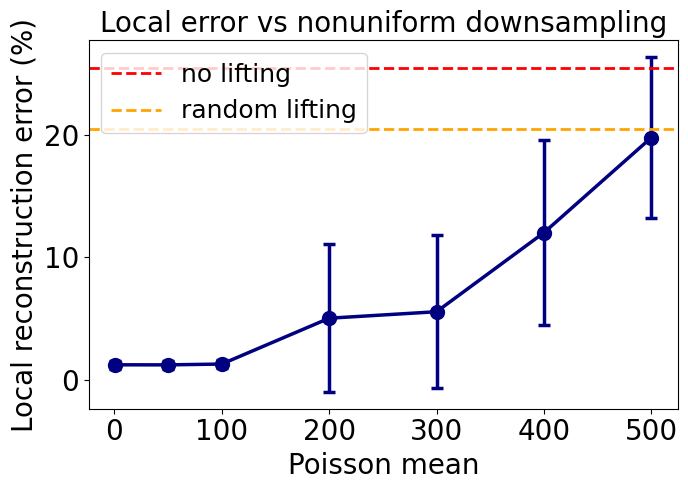

In [61]:
fig, ax = plot_local_error_distribution(path_global_error,
                                         save_dir, 
                                         #max_xvalue= 150,
                                         x_col = "mean_interval",
                                         xlabel = "Poisson mean",
                                         ylabel = "Local reconstruction error (%)",
                                         title = "Local error vs nonuniform downsampling",
                                         fig_path = os.path.join(save_dir, "nonuniform_downsample_local_simulation.pdf"),
                                         plot_null_errors = True
                                         )

## Sweep step size

In [50]:
path_global_error = "sweep_step_size/traj_step_size_sweep_results/traj_step_size_sweep_1holes.csv"


Figure saved to figures/traj_step_size_simulation.pdf


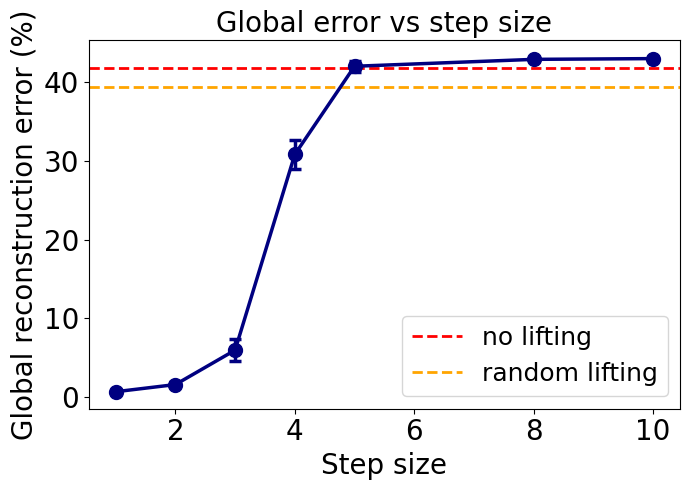

In [53]:
fig, ax= plot_global_error(path_global_error, 
            "Global error vs step size", 
            os.path.join(save_dir, "traj_step_size_simulation.pdf"), 
            x_col = "step_size",
            #max_x = 150,
            xlabel="Step size",
            ylabel="Global reconstruction error (%)",
            plot_null_errors = True,
            show=True)

Figure saved to figures/traj_step_size_local_simulation.pdf


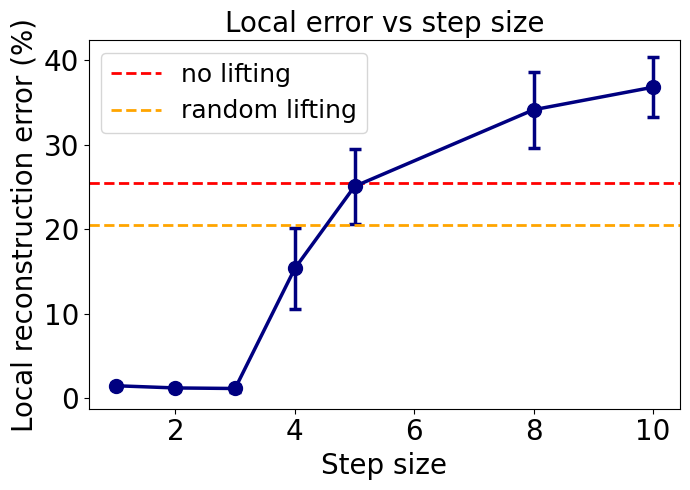

In [54]:
fig, ax = plot_local_error_distribution(path_global_error,
                                         save_dir, 
                                         #max_xvalue= 150,
                                         x_col = "step_size",
                                         xlabel = "Step size",
                                         ylabel = "Local reconstruction error (%)",
                                         title = "Local error vs step size",
                                         fig_path = os.path.join(save_dir, "traj_step_size_local_simulation.pdf"),
                                         plot_null_errors = True)

## time shift in neural activity

In [47]:
path_global_error = "../noise_neural_activity/3_temporal_shift/random_shift_sweep_1holes_dreimac.csv"
#"sweep_trajectory/random_shift_sweep_results/random_shift_sweep_1holes_dreimac.csv"

Figure saved to figures/time_shift_simulation.pdf


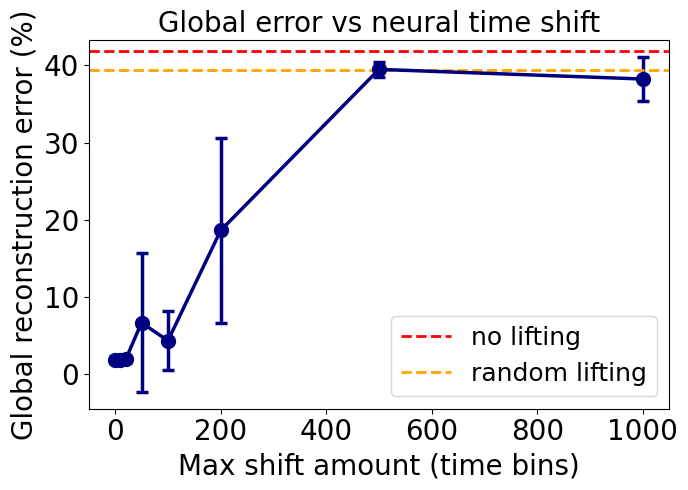

In [48]:
fig, ax= plot_global_error(path_global_error, 
            "Global error vs neural time shift", 
            os.path.join(save_dir, "time_shift_simulation.pdf"), 
            x_col = "shift_distance",
            #max_x = 150,
            xlabel="Max shift amount (time bins)",
            ylabel="Global reconstruction error (%)",
            plot_null_errors = True,
            show=True)

Figure saved to figures/time_shift_local_simulation.pdf


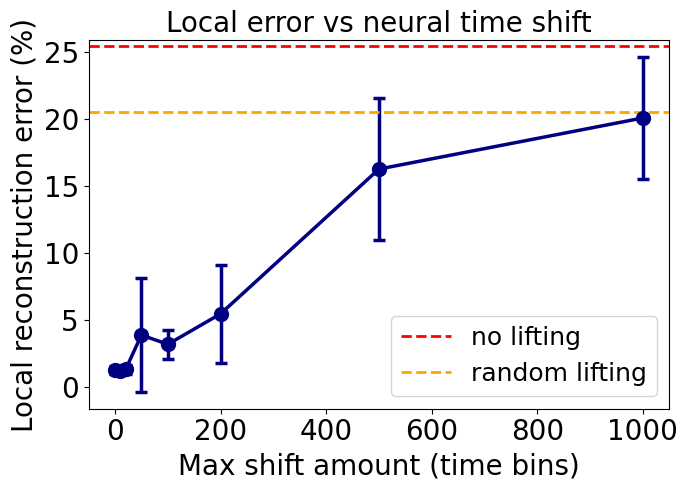

In [49]:
fig, ax = plot_local_error_distribution(path_global_error,
                                         save_dir, 
                                         #max_xvalue= 150,
                                         x_col = "shift_distance",
                                         xlabel = "Max shift amount (time bins)",
                                         ylabel = "Local reconstruction error (%)",
                                         title = "Local error vs neural time shift",
                                         fig_path = os.path.join(save_dir, "time_shift_local_simulation.pdf"),
                                         plot_null_errors = True
                                         )

## Sweep epsilon

In [8]:
path_epsilon = "sweep_epsilon/epsilon_sweep_results/epsilon_sweep_upgrade_1holes.csv"

Figure saved to revision_figures/epsilon_sweep_global_simulation.pdf


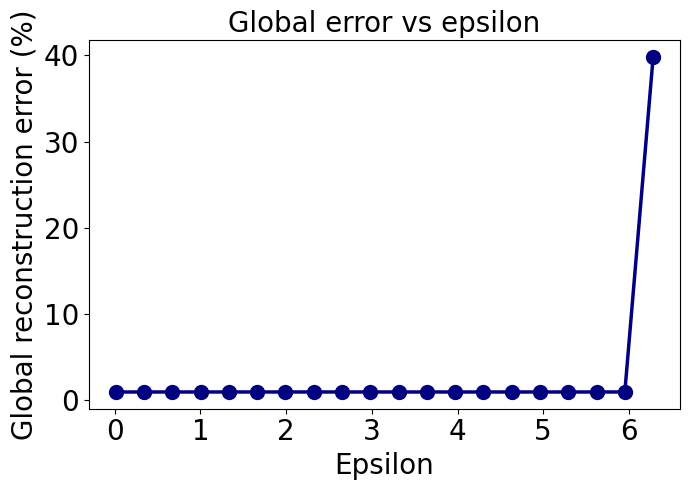

(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'Global error vs epsilon'}, xlabel='Epsilon', ylabel='Global reconstruction error (%)'>)

In [13]:
plot_global_error(path_epsilon,
                "Global error vs epsilon", 
                os.path.join(save_dir, "epsilon_sweep_global_simulation.pdf"),
                x_col = "epsilon",
                xlabel="Epsilon",
                ylabel="Global reconstruction error (%)",
                show=True)

In [6]:
path_epsilon = "sweep_epsilon/epsilon_sweep_gardner_results/epsilon_sweep_upgrade_Gardner.csv"

Figure saved to revision_figures/epsilon_sweep_global_2D.pdf


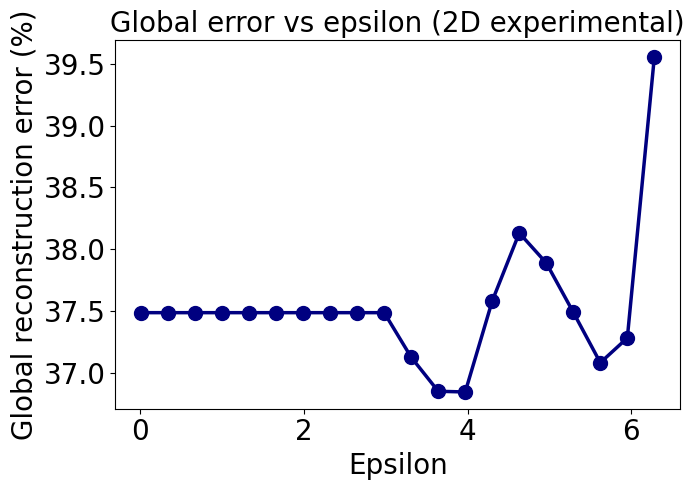

(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'Global error vs epsilon (2D experimental)'}, xlabel='Epsilon', ylabel='Global reconstruction error (%)'>)

In [7]:
plot_global_error(path_epsilon,
                "Global error vs epsilon (2D experimental)", 
                os.path.join(save_dir, "epsilon_sweep_global_2D.pdf"),
                x_col = "epsilon",
                xlabel="Epsilon",
                ylabel="Global reconstruction error (%)",
                show=True)

In [9]:
path_epsilon = "sweep_epsilon/epsilon_sweep_gardner_results/epsilon_sweep_segmental_upgrade_Gardner.csv"

Figure saved to revision_figures/epsilon_sweep_local_2D.pdf


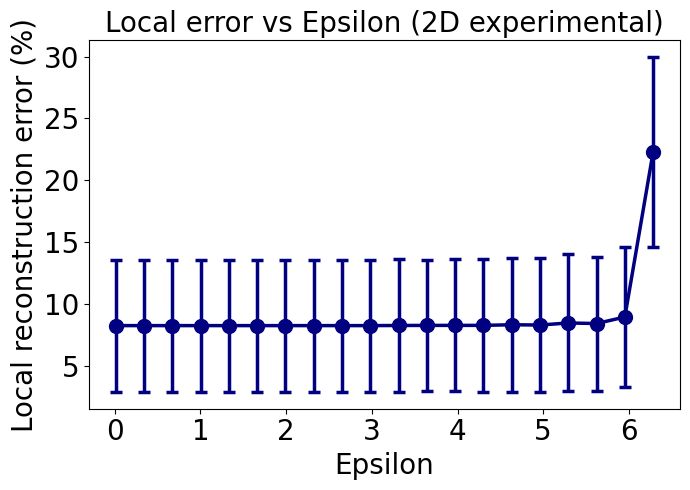

(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'Local error vs Epsilon (2D experimental)'}, xlabel='Epsilon', ylabel='Local reconstruction error (%)'>)

In [10]:
plot_segmental_error_summary(path_epsilon,
                             save_dir,
                             x_col = "epsilon",
                             mean_col = "seg_mismatch_mean",
                             std_col = "seg_mismatch_std",
                             xlabel="Epsilon",
                             ylabel="Local reconstruction error (%)",
                            title="Local error vs Epsilon (2D experimental)",
                                fig_path=os.path.join(save_dir, "epsilon_sweep_local_2D.pdf"))